### E-Commerce Sales Analysis 

#### Importing Libraries

In [319]:
import numpy as np
import pandas as pd

In [320]:
from mlxtend.frequent_patterns import apriori, association_rules

In [321]:
df = pd.read_csv("retail_data.csv", encoding='ISO-8859-1')

#### Data Exploration

In [322]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


In [323]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [324]:
df.shape

(541909, 8)

In [325]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

#### Data Transformation and Cleaning

In [326]:
df = df.dropna(subset = ["CustomerID"])   

In [327]:
df.shape

(406829, 8)

In [328]:
df = df[df['Quantity'] >0 ]

In [329]:
df = df[df['UnitPrice'] > 0 ]

In [330]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [331]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'] ,format ='mixed')

In [332]:
df['Monthly_Invoice'] = df['InvoiceDate'].dt.month   #INVOICES monthly

In [333]:
df['Yearly_Invoice'] = df['InvoiceDate'].dt.year     #INVOICES yearly

In [334]:
df['Day_wise_Invoice'] = df['InvoiceDate'].dt.day_name()    #INVOICES daywise

In [335]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Monthly_Invoice,Yearly_Invoice,Day_wise_Invoice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,2010,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,2010,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,Wednesday


In [336]:
df.shape

(397884, 12)

In [337]:
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending =False).head(10)

In [338]:
top_countries

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: TotalPrice, dtype: float64

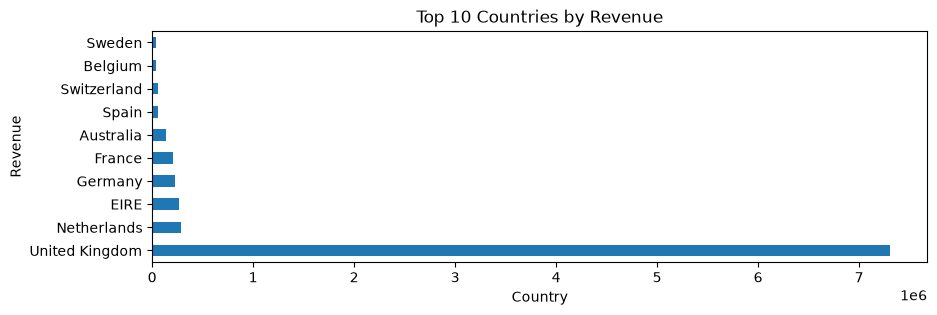

In [339]:
import matplotlib.pyplot as plt
top_countries.plot(kind='barh' , figsize=(10,3))  #pandas bcz x and y are known already

plt.title('Top 10 Countries by Revenue')   #matplotlib nowon
plt.xlabel('Country')
plt.ylabel('Revenue')

plt.show()

In [340]:
monthly_sales = df.groupby(['Yearly_Invoice' , 'Monthly_Invoice'])['TotalPrice'].sum()

monthly_sales

Yearly_Invoice  Monthly_Invoice
2010            12                  572713.890
2011            1                   569445.040
                2                   447137.350
                3                   595500.760
                4                   469200.361
                5                   678594.560
                6                   661213.690
                7                   600091.011
                8                   645343.900
                9                   952838.382
                10                 1039318.790
                11                 1161817.380
                12                  518192.790
Name: TotalPrice, dtype: float64

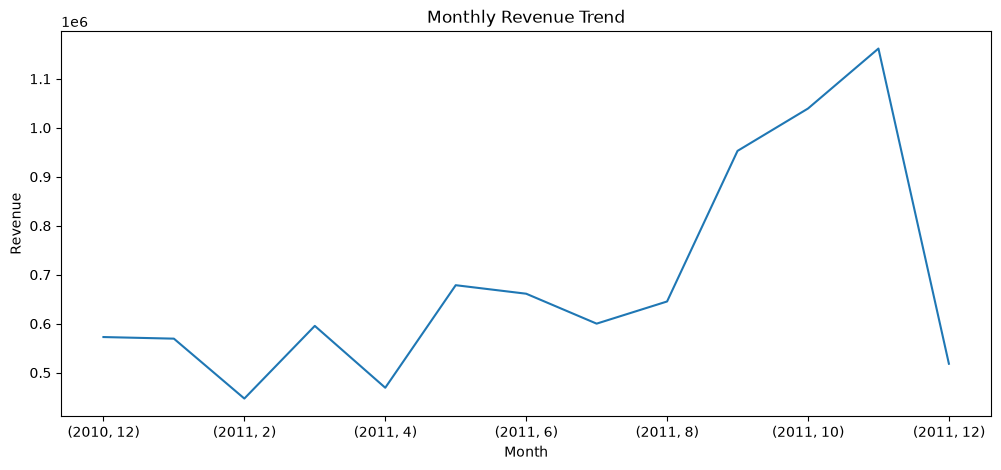

In [341]:
monthly_sales.plot(figsize=(12,5))

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

In [342]:

top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: TotalPrice, dtype: float64

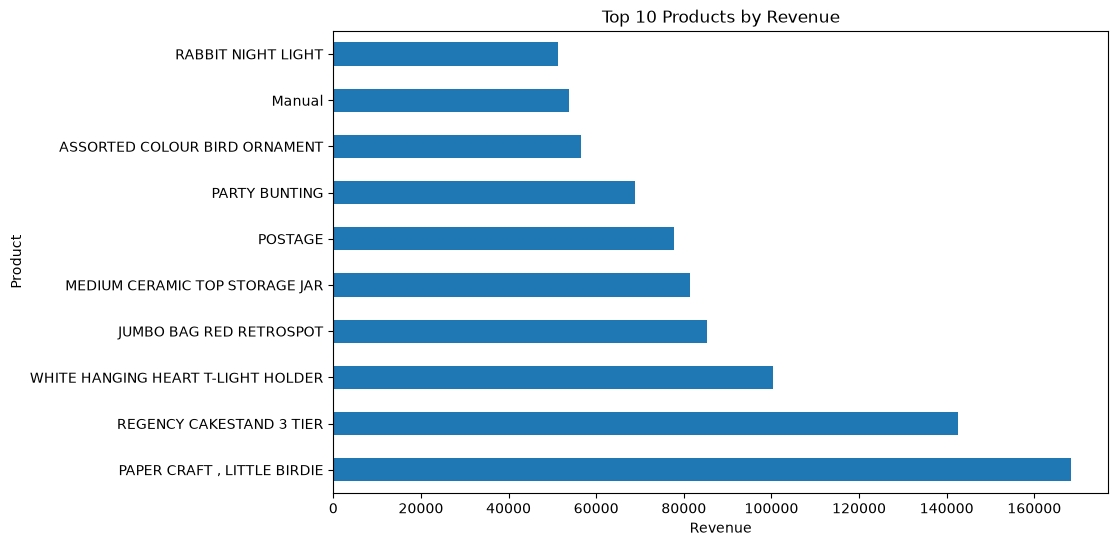

In [343]:
top_products.plot(kind='barh', figsize=(10,6))

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.show()

In [344]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending =False).head(10)
top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalPrice, dtype: float64

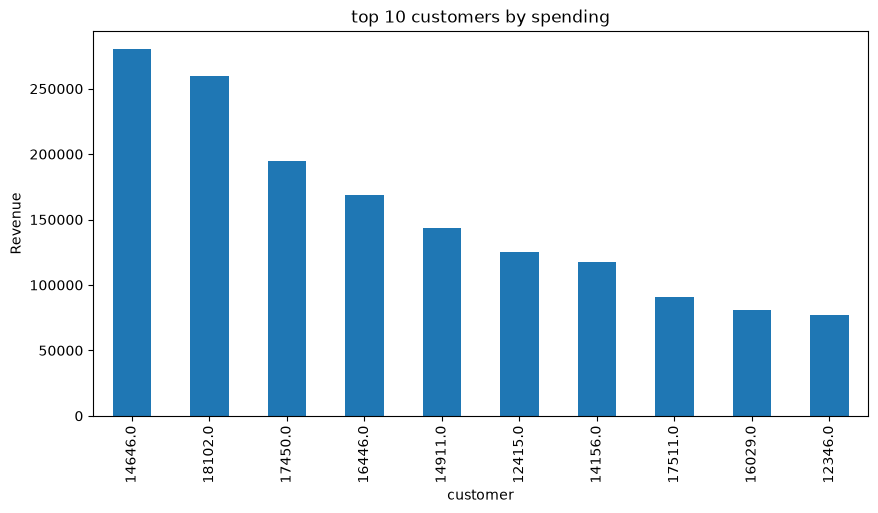

In [345]:
top_customers.plot(kind='bar', figsize=(10,5))

plt.title('top 10 customers by spending')
plt.xlabel('customer')
plt.ylabel('Revenue')

plt.show()


In [346]:
Sales_Day = df.groupby('Day_wise_Invoice')['TotalPrice'].sum().sort_values(ascending =False)

Sales_Day

Day_wise_Invoice
Thursday     1976859.070
Tuesday      1700634.631
Wednesday    1588336.170
Friday       1485917.401
Monday       1367146.411
Sunday        792514.221
Name: TotalPrice, dtype: float64

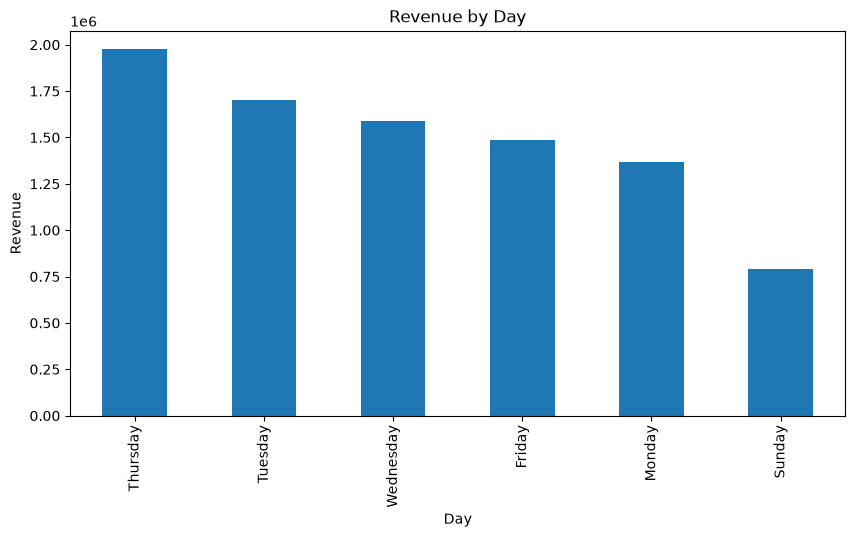

In [347]:
Sales_Day.plot(kind='bar', figsize=(10,5))

plt.title('Revenue by Day')
plt.xlabel('Day')
plt.ylabel('Revenue')

plt.show()

In [348]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [349]:
rfm = df.groupby('CustomerID').agg({ 'InvoiceDate': lambda x : (snapshot_date - x.max()).days,
                                     'InvoiceNo' : 'nunique' ,
                                     'TotalPrice' : 'sum'})

rfm

,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


In [350]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [351]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [352]:
rfm['R_Score'] = pd.qcut(rfm['Recency'],5,labels = [5,4,3,2,1])

In [353]:
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),5, labels=[1,2,3,4,5])
     

In [354]:
rfm['M_Score'] = pd.qcut(rfm['Monetary'],5,labels = [1,2,3,4,5])

In [355]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


In [356]:
def customer_segment(row):

    if row['RFM_Score'] == '555':
        return 'VIP Customers'

    elif row['R_Score'] == 5:
        return 'Loyal Customers'

    elif row['F_Score'] == 5:
        return 'Frequent Customers'

    elif row['M_Score'] == 5:
        return 'Big Spenders'

    else:
        return 'Regular Customers'

In [357]:
rfm['Segment'] = rfm.apply(customer_segment, axis=1) 
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,Big Spenders
12347.0,2,7,4310.00,5,5,5,555,VIP Customers
12348.0,75,4,1797.24,2,4,4,244,Regular Customers
12349.0,19,1,1757.55,4,1,4,414,Regular Customers
12350.0,310,1,334.40,1,1,2,112,Regular Customers


In [358]:
rfm['Segment'].value_counts()

Segment
Regular Customers     2860
Loyal Customers        520
Frequent Customers     429
VIP Customers          348
Big Spenders           181
Name: count, dtype: int64

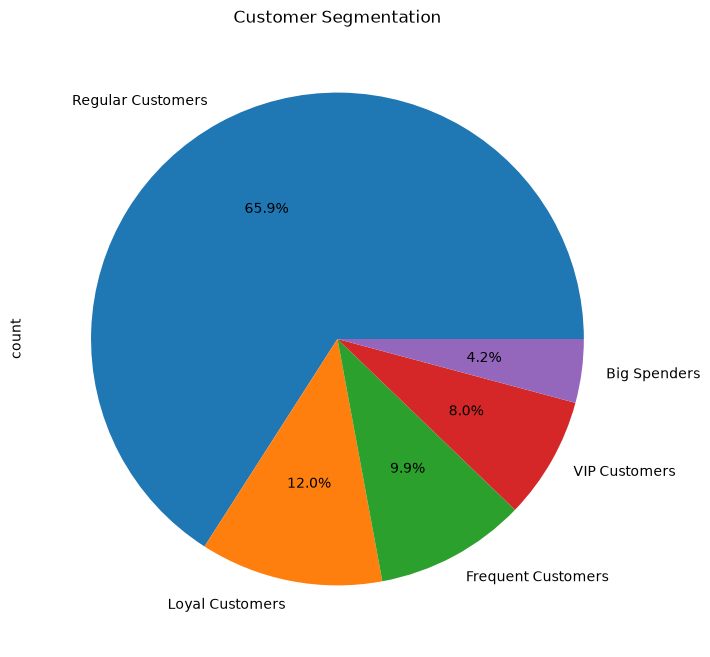

In [359]:
rfm['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(10,8))

plt.title('Customer Segmentation')

plt.show()

#### Market Basket Analysis

In [360]:
basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)

In [361]:
basket = basket.astype(bool)
basket = basket.map(lambda x: True if x > 0 else False)

In [362]:
items = apriori(basket, min_support=0.02,use_colnames=True )

In [363]:
rules = association_rules(
    items,
    metric='lift',
    min_threshold=1)

In [364]:
rules = rules[
    (rules['antecedents'].apply(len) == 1) &
    (rules['consequents'].apply(len) == 1) &
    (rules['confidence'] >= 0.5) &
    (rules['lift'] >= 2)
]

In [365]:
rules = rules.sort_values(
    'lift',
    ascending=False
)

In [366]:
rules[ ['antecedents', 'consequents','support', 'confidence', 'lift']].head(10)

,antecedents,consequents,support,confidence,lift
9,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.024822,0.827338,22.188466
8,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.024822,0.665702,22.188466
63,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.023527,0.784173,18.559754
62,(ROSES REGENCY TEACUP AND SAUCER ),(PINK REGENCY TEACUP AND SAUCER),0.023527,0.556833,18.559754
12,(ROSES REGENCY TEACUP AND SAUCER ),(GREEN REGENCY TEACUP AND SAUCER),0.029193,0.690932,18.530185
13,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.029193,0.782923,18.530185
4,(DOLLY GIRL LUNCH BOX),(SPACEBOY LUNCH BOX ),0.022879,0.688312,18.119023
5,(SPACEBOY LUNCH BOX ),(DOLLY GIRL LUNCH BOX),0.022879,0.602273,18.119023
6,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.024984,0.729134,17.873424
7,(GARDENERS KNEELING PAD KEEP CALM ),(GARDENERS KNEELING PAD CUP OF TEA ),0.024984,0.612434,17.873424


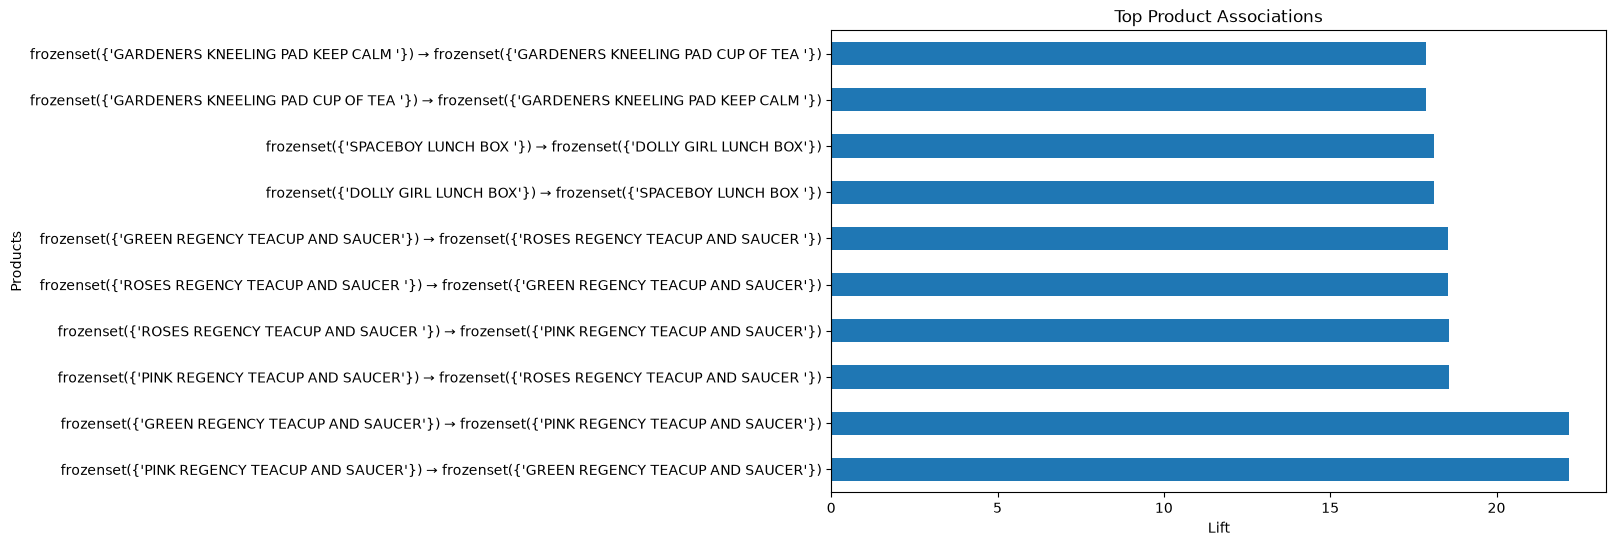

In [367]:
top_rules = rules.head(10).copy()

top_rules['Products'] = (
    top_rules['antecedents'].astype(str) +
    ' → ' +
    top_rules['consequents'].astype(str))

top_rules.plot(x='Products',
               y='lift',
               kind='barh',figsize=(10,6),legend=False)

plt.title('Top Product Associations')
plt.xlabel('Lift')
plt.ylabel('Products')
plt.show()

#### Customer lifetime Value

In [368]:
customer_data = df.groupby('CustomerID').agg(
    Revenue=('TotalPrice', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max')
).reset_index()

In [369]:
customer_data['Lifespan_Months'] = (
    (customer_data['LastPurchase'] - customer_data['FirstPurchase']).dt.days / 30
).clip(lower=1)

In [370]:
customer_data['Average_Order_Value'] = (
    customer_data['Revenue'] / customer_data['Orders'])

In [371]:
customer_data['Purchase_Frequency'] = (customer_data['Orders'] / customer_data['Lifespan_Months'])

In [372]:
customer_data['Estimated_CLV'] = (customer_data['Average_Order_Value'] *
                                  customer_data['Purchase_Frequency'] * 12)

In [376]:
customer_data.sort_values('Estimated_CLV',ascending=False).head(5)

,CustomerID,Revenue,Orders,FirstPurchase,LastPurchase,Lifespan_Months,Average_Order_Value,Purchase_Frequency,Estimated_CLV
0,12346.0,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00,1.000000,77183.600000,1.000000,926203.200000
2011,15098.0,39916.50,3,2011-06-10 15:22:00,2011-06-10 15:33:00,1.000000,13305.500000,3.000000,478998.000000
3008,16446.0,168472.50,2,2011-05-18 09:52:00,2011-12-09 09:15:00,6.800000,84236.250000,0.294118,297304.411765
1689,14646.0,280206.02,73,2010-12-20 10:09:00,2011-12-08 12:12:00,11.766667,3838.438630,6.203966,285762.513314
4201,18102.0,259657.30,60,2010-12-07 16:42:00,2011-12-09 11:50:00,12.200000,4327.621667,4.918033,255400.622951


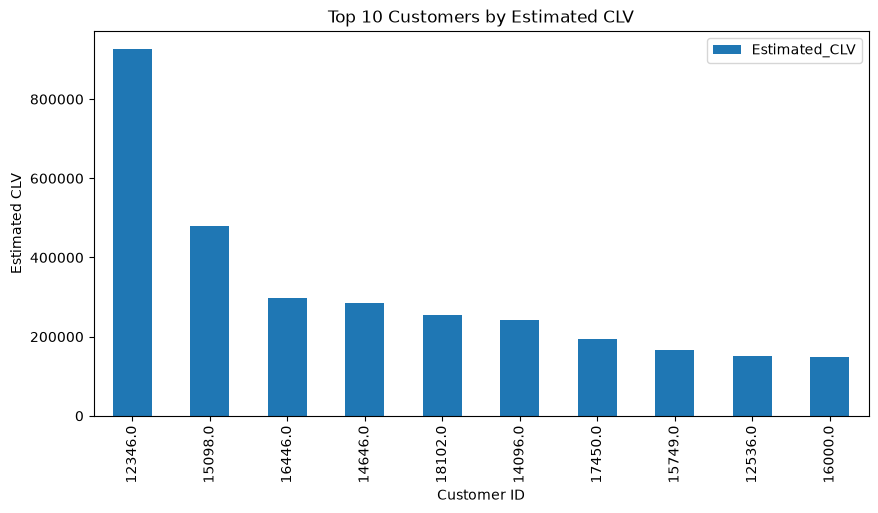

In [374]:
customer_data.nlargest(10, 'Estimated_CLV').plot(x='CustomerID',
                                                 y='Estimated_CLV',
                                                 kind='bar',
                                                 figsize=(10,5))

plt.title('Top 10 Customers by Estimated CLV')
plt.xlabel('Customer ID')
plt.ylabel('Estimated CLV')
plt.show()

#### Time Series Decomposition

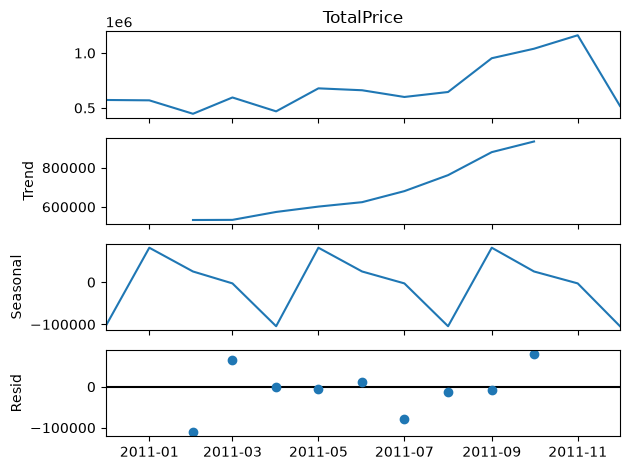

In [375]:
from statsmodels.tsa.seasonal import seasonal_decompose

monthly_sales = df.set_index('InvoiceDate')['TotalPrice'].resample('MS').sum()

decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=4
)

decomposition.plot()
plt.show()